# Weather Prediction NowCasting Model Scaffold

This notebook scaffolds a machine learning model to predict weather conditions based on data from InfluxDB.

### Objectives:
1.  **Data Ingestion**: Fetch data from locally hosted InfluxDB (Bucket: `OpenMeteo`).
2.  **Feature Engineering**: Create lags, rolling statistics, and temporal features.
3.  **Feature Selection**: Determine the most useful features.
4.  **Multi-target Prediction**: Predict `temperature`, `precipitation_probability`, and `wind_speed`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from influxdb_client import InfluxDBClient
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load environment variables from .env file
load_dotenv()

def fetch_influx_data(bucket="OpenMeteo", range_start="-365d"):
    """Fetches and pivots weather data from InfluxDB."""
    client = InfluxDBClient(
        url=os.getenv("INFLUXDB_URL"),
        token=os.getenv("INFLUXDB_TOKEN"),
        org=os.getenv("INFLUXDB_ORG")
    )
    query_api = client.query_api()

    query = f'''
    from(bucket: "{bucket}")
      |> range(start: {range_start})
      |> filter(fn: (r) => r["_measurement"] == "hourly_weather")
      |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
    '''

    # Query returns a list of dataframes if there are multiple tables
    df_list = query_api.query_data_frame(query)
    if isinstance(df_list, list):
        df = pd.concat(df_list)
    else:
        df = df_list

    # Cleanup columns
    cols_to_drop = ['result', 'table', '_start', '_stop', '_measurement']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # Set time as index
    df['_time'] = pd.to_datetime(df['_time'])
    df = df.rename(columns={'_time': 'time'})
    df = df.sort_values(['location', 'time'])

    return df

# Load data
df_raw = fetch_influx_data()
print(f"Data loaded. Shape: {df_raw.shape}")
print(f"Locations: {df_raw['location'].unique()}")
df_raw.head()


Data loaded. Shape: (26280, 10)
Locations: <StringArray>
['dubois', 'lander', 'pinedale']
Length: 3, dtype: str


,time,location,day,hour,month,precipitation,rain,relative_humidity,temperature,wind_speed
0,2025-02-19 14:00:00+00:00,dubois,19,14,2,0.0,0.0,80.367729,-11.646500,7.664280
1,2025-02-19 15:00:00+00:00,dubois,19,15,2,0.0,0.0,80.443871,-11.146500,8.654986
2,2025-02-19 16:00:00+00:00,dubois,19,16,2,0.0,0.0,75.089340,-7.596499,8.131936
3,2025-02-19 17:00:00+00:00,dubois,19,17,2,0.0,0.0,69.258598,-5.296500,10.036512
4,2025-02-19 18:00:00+00:00,dubois,19,18,2,0.0,0.0,60.245785,-2.596500,15.539537


### Feature Engineering

We will create several types of features:
1.  **Temporal Features**: Extract hour, day, month from timestamp.
2.  **Lagged Features**: Use past values (e.g., 1h, 3h, 6h ago) to predict future ones.
3.  **Rolling Statistics**: Moving averages and standard deviations to capture trends.


In [2]:
def engineer_features(df):
    # Create a copy to avoid SettingWithCopyWarning
    df = df.copy()

    # 1. Temporal Features
    df['hour'] = df['time'].dt.hour
    df['day_of_year'] = df['time'].dt.dayofyear
    df['month'] = df['time'].dt.month

    # Periodic encoding for cyclical features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # 2. Lagged Features (per location)
    lags = [1, 3, 6, 24]
    features_to_lag = ['temperature', 'precipitation', 'wind_speed', 'relative_humidity']

    for lag in lags:
        for col in features_to_lag:
            if col in df.columns:
                df[f'{col}_lag_{lag}'] = df.groupby('location')[col].shift(lag)

    # 3. Rolling Statistics (per location)
    windows = [6, 24]
    for window in windows:
        for col in features_to_lag:
            if col in df.columns:
                df[f'{col}_roll_mean_{window}'] = df.groupby('location')[col].transform(lambda x: x.rolling(window).mean())
                df[f'{col}_roll_std_{window}'] = df.groupby('location')[col].transform(lambda x: x.rolling(window).std())

    # Handle missing values created by lags/rolling windows
    df = df.dropna()

    return df

df_engineered = engineer_features(df_raw)
print(f"Feature Engineering complete. Shape: {df_engineered.shape}")

Feature Engineering complete. Shape: (26208, 45)


### Feature Selection & Correlation
Let's look at how features correlate with our targets: `temperature`, `precipitation_probability`, and `wind_speed`.


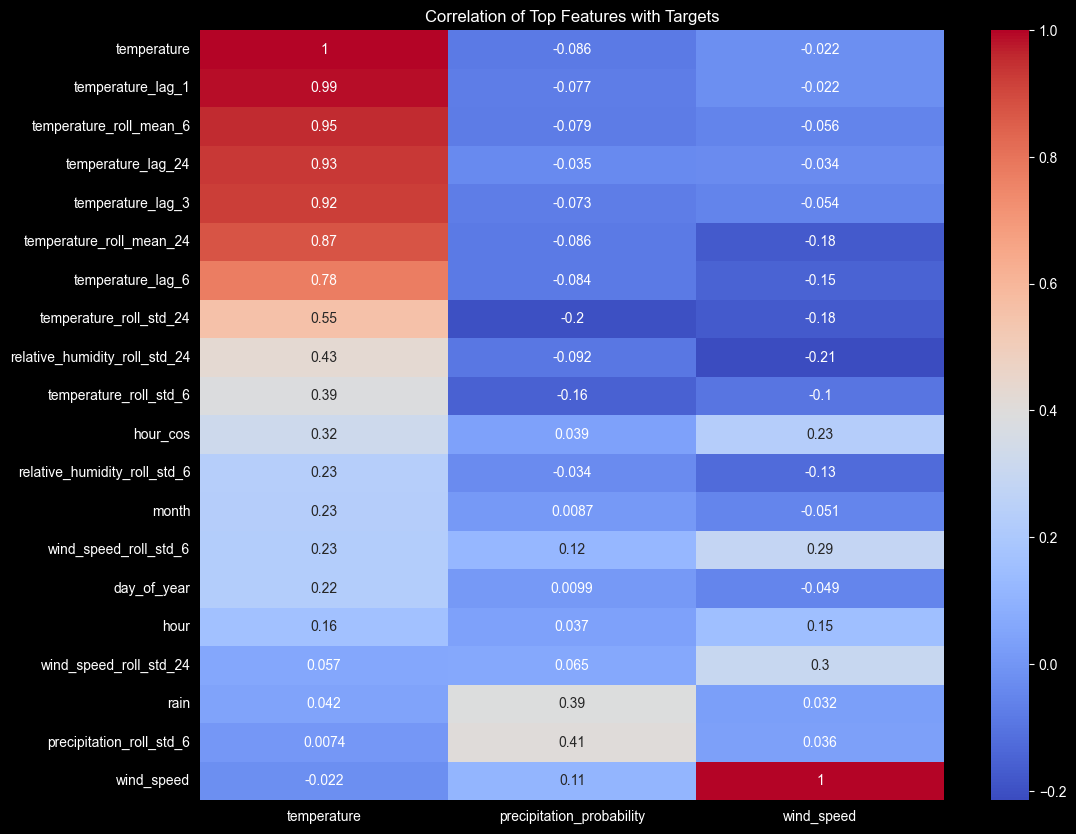

In [3]:
# Define targets
targets = ['temperature', 'precipitation_probability', 'wind_speed']

# Note: If precipitation_probability is missing in data, we can create a dummy or skip it for this scaffold
for target in targets:
    if target not in df_engineered.columns:
        print(f"Warning: {target} missing in data. Creating a placeholder (using 'precipitation' as proxy if available).")
        if target == 'precipitation_probability' and 'precipitation' in df_engineered.columns:
            df_engineered[target] = (df_engineered['precipitation'] > 0).astype(float)
        else:
            df_engineered[target] = 0.0

corr_matrix = df_engineered.drop(columns=['time', 'location']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[targets].sort_values(by=targets, ascending=False).head(20), annot=True, cmap='coolwarm')
plt.title("Correlation of Top Features with Targets")
plt.show()


### Model Training
We will use a `MultiOutputRegressor` wrapping a `RandomForestRegressor` to predict all three targets simultaneously.


In [4]:
# 1. Define Features and Targets
drop_cols = ['time', 'location'] + targets
X = df_engineered.drop(columns=drop_cols)
y = df_engineered[targets]

# 2. Encode categorical 'location' if we want to use it as a feature
X = pd.concat([X, pd.get_dummies(df_engineered['location'], prefix='loc')], axis=1)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Model Definition
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))

# 5. Fit Model
print("Training model...")
model.fit(X_train, y_train)
print("Training complete.")


Training model...
Training complete.


### Evaluation
Evaluate the model performance using RMSE and R² Score for each target.


Target: temperature               | RMSE: 0.6530 | R2: 0.9956
Target: precipitation_probability | RMSE: 0.0000 | R2: 1.0000
Target: wind_speed                | RMSE: 2.4420 | R2: 0.8873


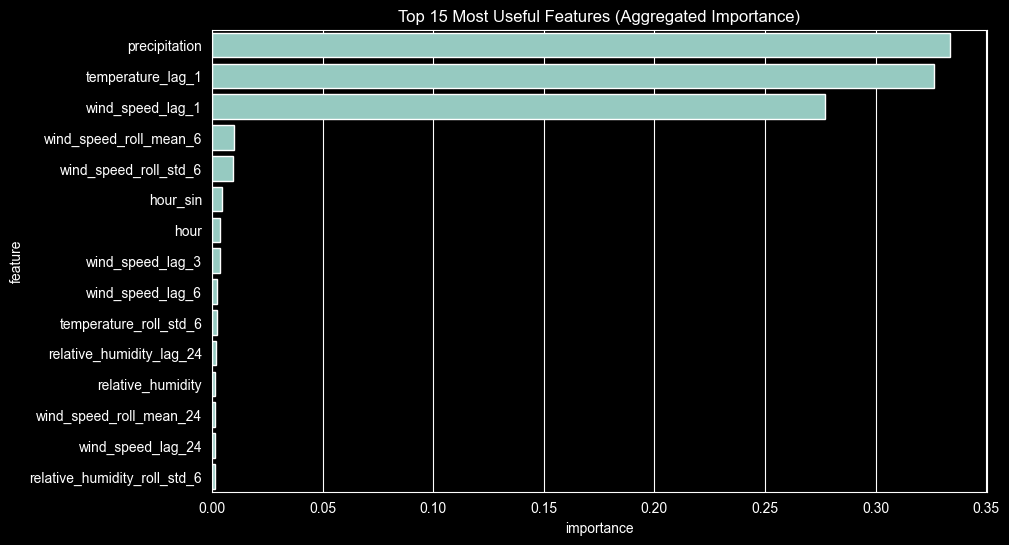

In [5]:
y_pred = model.predict(X_test)

for i, target in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"Target: {target:25} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

# Feature Importance for the Multi-Output Model (Aggregated)
importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)
feature_importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15))
plt.title("Top 15 Most Useful Features (Aggregated Importance)")
plt.show()


### Future Temperature Predictions Visualization
Visualize the "Nowcasted" temperature predictions against the actual values for the test period.


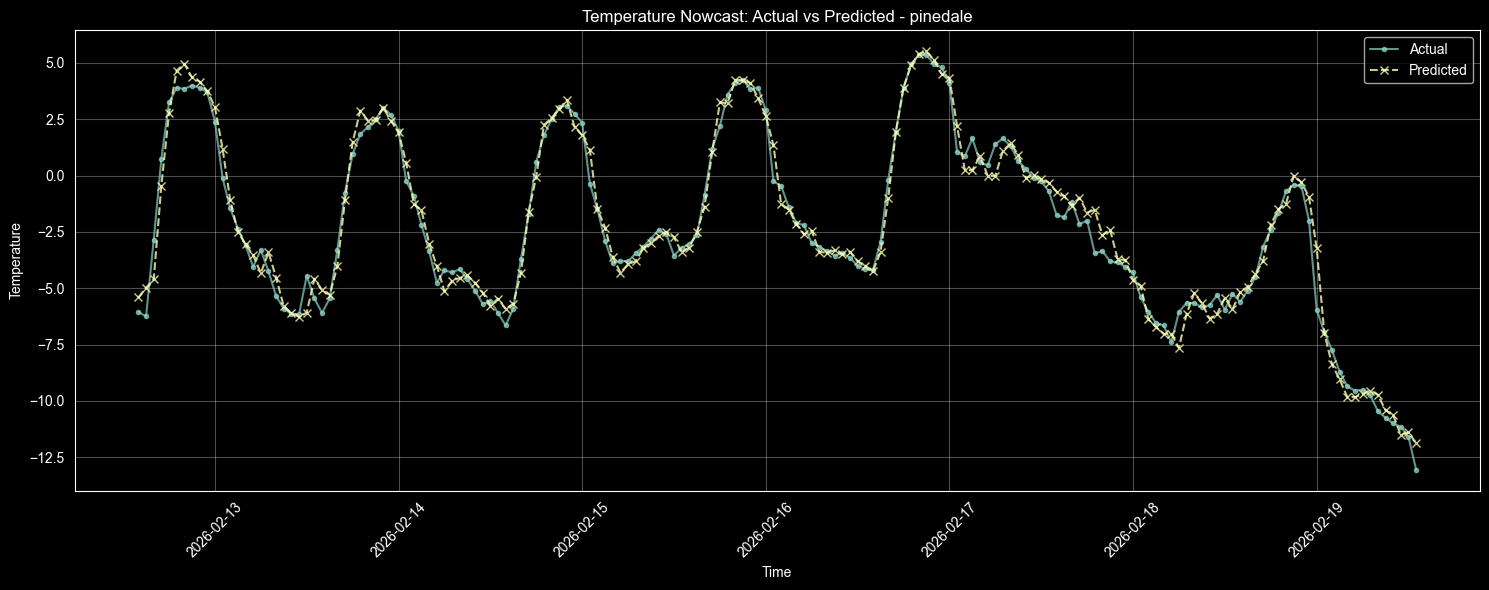

In [6]:
# Extract the time and location information for the test set
# Since we used shuffle=False in train_test_split, X_test corresponds to the last 20% of df_engineered
test_indices = X_test.index
df_test_info = df_engineered.loc[test_indices, ['time', 'location']]

# Create a DataFrame for visualization
viz_df = pd.DataFrame({
    'time': df_test_info['time'],
    'location': df_test_info['location'],
    'Actual Temperature': y_test['temperature'].values,
    'Predicted Temperature': y_pred[:, 0] # Temperature is the first target
})

# Plot for each location (or a specific one)
locations = viz_df['location'].unique()

for loc in locations:
    loc_data = viz_df[viz_df['location'] == loc].tail(168) # Show last 7 days for clarity

    plt.figure(figsize=(15, 6))
    plt.plot(loc_data['time'], loc_data['Actual Temperature'], label='Actual', marker='.', alpha=0.7)
    plt.plot(loc_data['time'], loc_data['Predicted Temperature'], label='Predicted', marker='x', linestyle='--', alpha=0.8)

    plt.title(f"Temperature Nowcast: Actual vs Predicted - {loc}")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
